# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Srinadh2314/srinadh-flyrank-intership/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

This study asks which pages should be reviewed first for a possible content refresh using observable search and content signals. A Random Forest was trained using February 2026 feature-window data and evaluated against a simple warehouse-native visibility baseline using a client-grouped test split. The Random Forest achieved Precision@50 of 0.960 compared with 0.000 for the baseline on the chosen March outcome proxy. The model relied most strongly on average GSC impressions and average GSC position in this evaluation. These results provide directional decision-support for prioritizing human review and should not be interpreted as causal evidence that refreshing a page will improve its performance.


# Research Question

Which pages should be reviewed first for a possible content refresh based on observable search and content signals?

# Decision supported

The output is intended to help a content reviewer prioritize limited review time. The model produces a ranked list of pages that can be inspected first, while the final decision about whether to refresh, expand, protect, prune, or monitor a page remains with the reviewer.

# Research framing

This is a decision-support problem rather than an attempt to predict Google's ranking algorithm or prove that a content refresh will cause improvement.

In [46]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF_TOKEN loaded successfully")

HF_TOKEN loaded successfully


In [47]:
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

print("Warehouse connection ready")

Warehouse connection ready


In [48]:
print("Lane: Refresh / Content Opportunity Scoring")
print("Goal: Rank pages for human review.")
print("Decision: Which pages should be reviewed first?")

Lane: Refresh / Content Opportunity Scoring
Goal: Rank pages for human review.
Decision: Which pages should be reviewed first?


## 2. Data

# Data

The analysis uses the FlyRank internship warehouse release accessed through Hugging Face. The feature window is February 2026 and the outcome window is March 2026.

The main daily performance table is `fact_content_daily_performance`. The analysis uses anonymized client and content identifiers together with observable search and analytics signals.

The modeling features are:
- `avg_gsc_impressions`
- `avg_gsc_clicks`
- `avg_gsc_avg_position`
- `avg_ga4_sessions`
- `avg_scroll_events`

Future outcome information is not used as a model feature. The March outcome is used only to define the target proxy. Client and content identifiers are used for grouping and joins, not as predictive features.

The final-month `_sample` data is not used for feature development because it represents the sealed final outcome month.

In [49]:
print("Feature window: February 2026")
print("Outcome window: March 2026")
print("Model features: 5")
print("Evaluation split: client-grouped")

Feature window: February 2026
Outcome window: March 2026
Model features: 5
Evaluation split: client-grouped


## 3. Methodology

# Methodology

The unit of analysis is one client-content item.

Five observable feature-window signals are used: GSC impressions, GSC clicks, average GSC position, GA4 sessions, and scroll events.

The target is a proxy based on the March outcome window: whether March GSC impressions were zero. This is treated as an observed outcome proxy, not as direct proof that a page needs a refresh.

The baseline is a simple warehouse-native visibility rule based on February average GSC impressions. The Random Forest combines all five observable features and can capture non-linear relationships between them.

Validation uses a client-grouped train/test split. All pages belonging to a client remain in the same split, producing zero client overlap between training and test data.

Leakage was explicitly tested by introducing a future March field. That deliberate experiment produced an apparently perfect Precision@50 of 1.000, demonstrating why future outcome information must not be used as a feature. The leaked feature was then removed from the honest feature set.

The main evaluation metric is Precision@50 because the practical use case is to prioritize the first 50 pages for limited human review time.

In [50]:
import pandas as pd
import numpy as np
import duckdb
from sklearn.model_selection import GroupShuffleSplit

# February 2026 = feature window
feature_query = """
SELECT
    client_hash_id,
    content_hash_id,
    AVG(gsc_impressions) AS avg_gsc_impressions,
    AVG(gsc_clicks) AS avg_gsc_clicks,
    AVG(gsc_avg_position) AS avg_gsc_avg_position,
    AVG(ga4_sessions) AS avg_ga4_sessions,
    AVG(scroll_events) AS avg_scroll_events
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet'
)
GROUP BY client_hash_id, content_hash_id
"""

feature_df = con.execute(feature_query).df()

# March 2026 = outcome window
label_query = """
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS march_impressions
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
GROUP BY client_hash_id, content_hash_id
"""

label_df = con.execute(label_query).df()

# Join feature and outcome windows
model_df = feature_df.merge(
    label_df,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

# Outcome proxy
model_df["target"] = (
    model_df["march_impressions"] == 0
).astype(int)

# Client-grouped train/test split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_df,
        y=model_df["target"],
        groups=model_df["client_hash_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

client_overlap = (
    set(train_df["client_hash_id"])
    & set(test_df["client_hash_id"])
)

print("Model dataset rows:", len(model_df))
print("Target rate:", round(model_df["target"].mean(), 3))
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Training clients:", train_df["client_hash_id"].nunique())
print("Test clients:", test_df["client_hash_id"].nunique())
print("Client overlap:", len(client_overlap))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model dataset rows: 303572
Target rate: 0.468
Training rows: 264134
Test rows: 39438
Training clients: 40
Test clients: 10
Client overlap: 0




## 4. Results (vs baseline)

On the client-held-out test set, the warehouse-native visibility baseline achieved Precision@50 of 0.000, while the Random Forest achieved Precision@50 of 0.960.

In this evaluation, 48 of the top 50 Random Forest-ranked rows matched the target proxy. There were 2 non-target rows in the top 50.

The Random Forest therefore ranked the selected outcome proxy more effectively than the simple baseline on this particular split. This is a measured result for the chosen proxy and validation design; it does not mean that 96% of pages need a refresh or that refreshing them will improve performance.

In [51]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

features = [
    "avg_gsc_impressions",
    "avg_gsc_clicks",
    "avg_gsc_avg_position",
    "avg_ga4_sessions",
    "avg_scroll_events"
]

# Prepare train/test data
X_train = train_df[features].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

X_test = test_df[features].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

y_train = train_df["target"]
y_test = test_df["target"]

# -----------------------------
# Baseline
# -----------------------------
baseline_score = test_df["avg_gsc_impressions"].fillna(0)

# -----------------------------
# Random Forest
# -----------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

model_score = model.predict_proba(X_test)[:, 1]

# -----------------------------
# Precision@50
# -----------------------------
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(labels)[order].mean()

baseline_p50 = precision_at_k(
    baseline_score,
    y_test.values,
    50
)

model_p50 = precision_at_k(
    model_score,
    y_test.values,
    50
)

# -----------------------------
# Results table
# -----------------------------
results = pd.DataFrame({
    "method": [
        "Warehouse baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

display(results)

print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Random Forest Precision@50: {model_p50:.3f}")
print(f"Difference: {(model_p50 - baseline_p50):+.3f}")

,method,Precision@50
0,Warehouse baseline,0.00
1,Random Forest,0.96


Baseline Precision@50: 0.000
Random Forest Precision@50: 0.960
Difference: +0.960


## 5. Limitations


# Limitations and honest framing

This analysis has several limitations.

First, the target is a proxy based on zero March GSC impressions. It is not a direct label for whether a page actually needs a content refresh.

Second, the model was evaluated on one client-grouped split. Results may change on different clients, time periods, or target definitions.

Third, some warehouse signals have missing values, so not every client-content item has every feature available.

Fourth, Precision@50 focuses on the highest-priority 50 rows and does not describe the entire ranking.

Finally, the analysis is observational. It can identify measured and directional patterns and provide decision-support, but it cannot prove that a content action caused an improvement or predict Google's ranking algorithm.
A zero March-impressions outcome may also reflect data-availability conditions, so the target is treated as an outcome proxy rather than a direct measure of content quality or refresh need.

In [52]:
print("Model dataset rows:", len(model_df))

print("\nMissing values by model feature:")
missing_values = (
    model_df[features]
    .isna()
    .sum()
    .to_frame("missing_rows")
)

display(missing_values)

Model dataset rows: 303572

Missing values by model feature:


,missing_rows
avg_gsc_impressions,0
avg_gsc_clicks,0
avg_gsc_avg_position,158293
avg_ga4_sessions,131711
avg_scroll_events,131711


## 6. Ranked recommendations

**Ranking note**

Several recommendations have tied model scores. Therefore, the exact order within a tied group should not be interpreted as a meaningful difference in priority. The ranking is best used to identify a high-priority review set, after which a human reviewer should inspect the pages and decide the appropriate action.

In [53]:
# Create the final ranked recommendation queue

recommendations = test_df[
    ["client_hash_id", "content_hash_id"] + features
].copy()

recommendations["model_score"] = model_score

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = np.arange(
    1, len(recommendations) + 1
)

recommendations["action"] = np.where(
    recommendations["rank"] <= 50,
    "REVIEW_FIRST",
    "LOWER_PRIORITY"
)

recommendations["reason_code"] = np.where(
    recommendations["rank"] <= 50,
    "MODEL_HIGH_PRIORITY",
    "MODEL_LOWER_PRIORITY"
)

recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code"
    ]
]

print("Top 20 ranked recommendations:")
display(recommendations.head(20))

Top 20 ranked recommendations:


,rank,client_hash_id,content_hash_id,model_score,action,reason_code
0,1,client_59256b0571e0c970,content_4ad2c9181210b3cc,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
1,2,client_764ae36a94e30a25,content_d70713f30a4280b0,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
2,3,client_764ae36a94e30a25,content_69f20032220e428b,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
3,4,client_59256b0571e0c970,content_2acee4630d996a40,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
4,5,client_59256b0571e0c970,content_2a145009192dbd8e,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
5,6,client_764ae36a94e30a25,content_7311f347ffa31c6b,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
6,7,client_764ae36a94e30a25,content_79db5d49abb12019,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
7,8,client_59256b0571e0c970,content_965dd8246efb1354,0.964686,REVIEW_FIRST,MODEL_HIGH_PRIORITY
8,9,client_59256b0571e0c970,content_c494a02d2c277357,0.950249,REVIEW_FIRST,MODEL_HIGH_PRIORITY
9,10,client_764ae36a94e30a25,content_df61e5a81797d585,0.950249,REVIEW_FIRST,MODEL_HIGH_PRIORITY


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

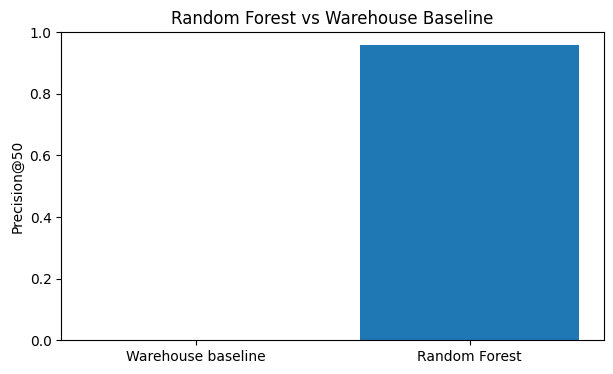

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(
    results["method"],
    results["Precision@50"]
)
plt.ylabel("Precision@50")
plt.title("Random Forest vs Warehouse Baseline")
plt.ylim(0, 1)
plt.show()

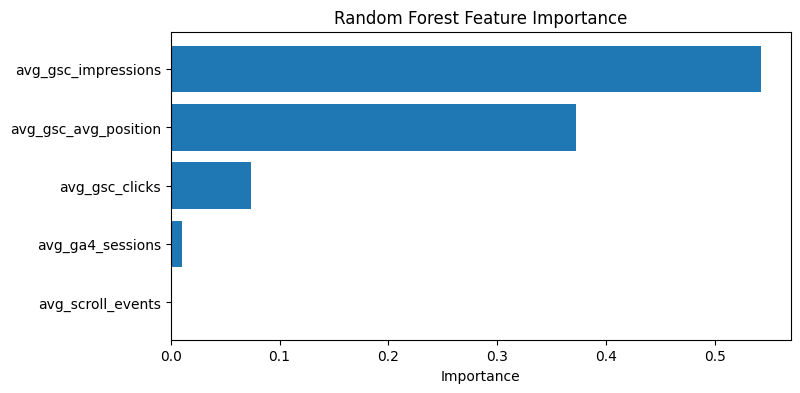

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))

plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

## Reproducibility

The analysis is implemented in the capstone notebook in the project repository. The notebook loads the FlyRank internship warehouse through DuckDB, builds the February 2026 feature window, creates the March 2026 outcome proxy, performs a client-grouped train/test split, trains the Random Forest, evaluates Precision@50, and generates the ranked recommendation output and figures.

Repository:
https://github.com/Srinadh2314/srinadh-flyrank-intership

## ML-12 — 5-minute demo outline

**0:00–0:45 — Problem**
Which pages should be reviewed first for a possible content refresh?

**0:45–1:30 — Data**
Explain the February feature window, March outcome window, five observable features, and client-grouped validation.

**1:30–2:30 — Baseline vs model**
Show the Precision@50 comparison:
- Warehouse baseline: 0.000
- Random Forest: 0.960

**2:30–3:30 — What the model learned**
Explain that average GSC impressions and average GSC position were the strongest feature-importance signals.

**3:30–4:30 — Recommendations**
Show the ranked review queue and explain that it is decision-support for human review.

**4:30–5:00 — Limitations**
Explain the outcome proxy, missing data, tied scores, and why the result does not prove causal refresh impact.

## Social-post cut

I built a search-content prioritization workflow using the FlyRank internship warehouse. A client-grouped Random Forest achieved Precision@50 of 0.960 versus 0.000 for a simple warehouse visibility baseline on the selected outcome proxy. The result is directional decision-support for prioritizing human review, not proof of causal content impact.

## Employer-facing summary

I built an end-to-end ML workflow that turns search and content signals into a prioritized review queue. I used a client-grouped validation design, explicit leakage checks, a transparent baseline, and a Random Forest model, with Precision@50 as the main ranking metric. The project demonstrates practical model evaluation, feature interpretation, and responsible use of ML for decision-support.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: https://flyrank.ai

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
